<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/main_strk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIBLIOTECAS

In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# DRIVE

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# WINDOW

In [3]:
def window(N, wt):

    nn = N - 1
    pn = 2 * np.pi * np.arange(0, nn + 1) / nn

    if wt[:4] == 'rect':
        w = np.ones(N)

    elif wt[:4] == 'tria':
        m = nn // 2
        w = np.arange(0, m + 1) / m
        w = np.concatenate([w, w[::-1][1:]])

    elif wt[:4] == 'hann':
        w = 0.5 * (1 - np.cos(pn))

    elif wt[:4] == 'hamm':
        w = 0.54 - 0.46 * np.cos(pn)

    elif wt[:4] == 'blac':
        w = (
            0.42
            - 0.5 * np.cos(pn)
            + 0.08 * np.cos(2 * pn)
        )

    else:
        raise ValueError('Tipo de janela inválido')

    return w

# WEIM

In [4]:
def weim(N, wt, x):

    w = window(N, wt)

    x = np.array(x).flatten()

    ln = (N - 1) // 2
    lx = len(x)
    lf = lx - ln

    y = np.zeros_like(x)

    for i in range(lx):

        # início
        if i < ln:

            y[i] = (
                np.sum(x[:ln+i+1] * w[ln-i:])
                / np.sum(w[ln-i:])
            )

        # centro
        elif i >= ln and i < lf:

            y[i] = (
                np.sum(x[i-ln:i+ln+1] * w)
                / np.sum(w)
            )

        # final
        else:

            y[i] = (
                np.sum(x[i-ln:] * w[:len(x[i-ln:])])
                / np.sum(w[:len(x[i-ln:])])
            )

    return y

# PROCESSAMENTO

In [5]:
# =========================================================
# PROCESSAMENTO SURFACE TRACK
# =========================================================

def processar_strk(caminho_pasta, nome_saida):

    # procurar arquivos
    arquivos = sorted(
        glob(os.path.join(caminho_pasta, '*.txt'))
    )

    lista_df = []

    for arq in arquivos:

        nome_arquivo = os.path.basename(arq)

        # =================================================
        # EXTRAIR DATA
        # =================================================

        data_str = (
            nome_arquivo
            .replace('STrk', '')
            .replace('.txt', '')
        )

        data_inicial = pd.to_datetime(
            data_str,
            format='%Y%m%d%H%M%S%f'
        )

        # =================================================
        # LEITURA ROBUSTA
        # =================================================

        dados = np.loadtxt(
          arq,
          comments='%'
        )

        # garantir matriz Nx4
        if dados.ndim == 1:

            continue

        # substituir inválidos por NaN
        dados[dados == 0] = np.nan
        dados[dados == -32768] = np.nan

        # mm -> m
        dados = dados / 1000

        # dataframe
        dados = pd.DataFrame(
            dados,
            columns=['B1_m', 'B2_m', 'B3_m', 'B4_m']
        )

        # interpolar NaN
        for col in ['B1_m', 'B2_m', 'B3_m', 'B4_m']:

            dados[col] = (
                dados[col]
                .interpolate()
                .ffill()
                .bfill()
            )

        # =================================================
        # REMOVER MARÉ INDIVIDUALMENTE
        # =================================================

        dados['B1_h'] = (
            dados['B1_m']
            - weim(275, 'blac', dados['B1_m'])
        )

        dados['B2_h'] = (
            dados['B2_m']
            - weim(275, 'blac', dados['B2_m'])
        )

        dados['B3_h'] = (
            dados['B3_m']
            - weim(275, 'blac', dados['B3_m'])
        )

        dados['B4_h'] = (
            dados['B4_m']
            - weim(275, 'blac', dados['B4_m'])
        )

        # =================================================
        # EMPILHAR OS 4 BEAMS
        # =================================================

        serie = dados[
            ['B1_h', 'B2_h', 'B3_h', 'B4_h']
        ].to_numpy().flatten()

        # =================================================
        # NOVO DATAFRAME
        # =================================================

        dados_final = pd.DataFrame({
            'altura_h': serie
        })

        # =================================================
        # TEMPO
        # 4 beams x 2 Hz = 8 Hz
        # dt = 0.125 s
        # =================================================

        tempo = pd.date_range(
            start=data_inicial,
            periods=len(dados_final),
            freq='125ms'
        )

        dados_final['DataHora'] = tempo

        # reorganizar colunas
        dados_final = dados_final[
            ['DataHora', 'altura_h']
        ]

        lista_df.append(dados_final)

    # =====================================================
    # CONCATENAR
    # =====================================================

    df_final = pd.concat(
        lista_df,
        ignore_index=True
    )

    # ordenar
    df_final = df_final.sort_values(
        'DataHora'
    )

    # reset índice
    df_final = df_final.reset_index(
        drop=True
    )

    # =====================================================
    # CORTES TEMPORAIS
    # =====================================================

    if nome_saida == 'Strk_CHU':

        inicio = pd.to_datetime(
            '2025-03-27 13:20:00'
        )

        fim = pd.to_datetime(
            '2025-04-02 16:00:00'
        )

        df_final = df_final[
            (df_final['DataHora'] >= inicio) &
            (df_final['DataHora'] <= fim)
        ]

    if nome_saida == 'Strk_SEC':

        inicio = pd.to_datetime(
            '2025-11-22 18:00:00'
        )

        fim = pd.to_datetime(
            '2025-11-30 09:00:00'
        )

        df_final = df_final[
            (df_final['DataHora'] >= inicio) &
            (df_final['DataHora'] <= fim)
        ]

    # reset índice
    df_final = df_final.reset_index(
        drop=True
    )

    # =====================================================
    # SALVAR CSV
    # =====================================================

    caminho_saida = (
        f'/content/drive/MyDrive/Ondas/Dados/Refinados/{nome_saida}.csv'
    )

    df_final.to_csv(
        caminho_saida,
        index=False,
        date_format='%Y-%m-%d %H:%M:%S.%f'
    )

    return df_final

# CHUVOSO

In [6]:
caminho_chu = (
    '/content/drive/MyDrive/Ondas/Dados/marco2025/SCO1/Strk'
)

Strk_CHU = processar_strk(
    caminho_chu,
    'Strk_CHU'
)


# MENOS CHUVOSO

In [7]:
caminho_sec = (
    '/content/drive/MyDrive/Ondas/Dados/novembro2025/SCO2/STrk_2'
)

Strk_SEC = processar_strk(
    caminho_sec,
    'Strk_SEC'
)

# 1o PLOT

## Formatação dos plots

In [8]:
# fonte serif
plt.rcParams['font.family'] = 'serif'

# virgula no lugar de .
def comma_formatter(x, pos):

    return (
        f'{x:,.2f}'
        .replace('.', 'X')
        .replace(',', '.')
        .replace('X', ',')
    )

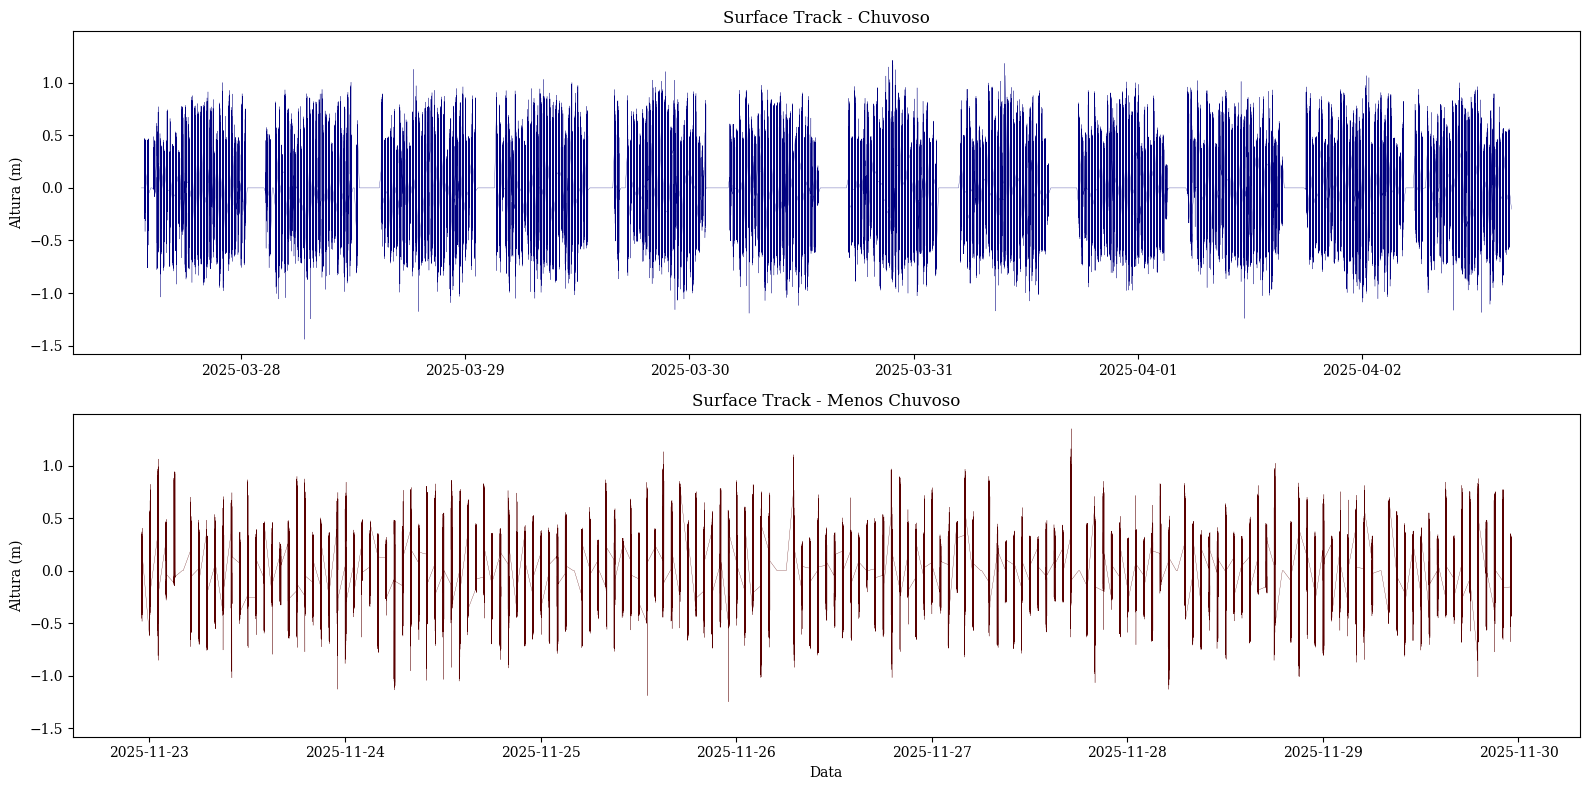

In [22]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# CHUVOSO

ax[0].plot(
    Strk_CHU['DataHora'],
    Strk_CHU['altura_h'],
    color='navy',
    linewidth=0.2
)

ax[0].set_title('Surface Track - Chuvoso')
ax[0].set_ylabel('Altura (m)')

# MENOS CHUVOSO

ax[1].plot(
    Strk_SEC['DataHora'],
    Strk_SEC['altura_h'],
    color='#5A0000',
    linewidth=0.2
)

ax[1].set_title('Surface Track - Menos Chuvoso')
ax[1].set_ylabel('Altura (m)')
ax[1].set_xlabel('Data')

plt.tight_layout()
plt.show()

# DF Individuais

In [10]:
# DF individuais

df_strk_chu = Strk_CHU.copy()
df_strk_sec = Strk_SEC.copy()

# garantir datetime

df_strk_chu['DataHora'] = pd.to_datetime(
    df_strk_chu['DataHora']
)

df_strk_sec['DataHora'] = pd.to_datetime(
    df_strk_sec['DataHora']
)

# Identificando ondas

In [11]:
def individual_waves(serie):

    serie = np.array(serie)

    cruz = np.where(
        (serie[:-1] < 0) &
        (serie[1:] >= 0)
    )[0]

    alturas = []

    for i in range(len(cruz)-1):

        trecho = serie[
            cruz[i]:cruz[i+1]
        ]

        if len(trecho) > 0:

            H = (
                np.max(trecho)
                - np.min(trecho)
            )

            alturas.append(H)

    return np.array(alturas)

# Def Hs

In [12]:

def calc_hs_series(serie):

    alturas = individual_waves(serie)

    if len(alturas) == 0:
        return np.nan

    alturas = np.sort(alturas)[::-1]

    n = int(len(alturas) / 3)

    if n == 0:
        return np.nan

    hs = np.mean(alturas[:n])

    return hs

# Hs Geral

In [13]:
HsChu_strk = calc_hs_series(
    df_strk_chu['altura_h']
)

HsSec_strk = calc_hs_series(
    df_strk_sec['altura_h']
)

print(f'Hs STRK Chuvoso = {HsChu_strk:.3f} m')
print(f'Hs STRK Seco = {HsSec_strk:.3f} m')

Hs STRK Chuvoso = 0.665 m
Hs STRK Seco = 0.581 m


# Def intervalados

In [14]:
def calc_hs_intervalo(df, intervalo):

    resultados = []

    grupos = df.resample(
        intervalo,
        on='DataHora'
    )

    for tempo, grupo in grupos:

        if len(grupo) > 10:

            hs = calc_hs_series(
                grupo['altura_h']
            )

            resultados.append([
                tempo,
                hs
            ])

    df_hs = pd.DataFrame(
        resultados,
        columns=['DataHora', 'Hs']
    )

    return df_hs

# Hs 10min

In [15]:
df_Hs_10min_CHU_STRK = calc_hs_intervalo(
    df_strk_chu,
    '10min'
)

df_Hs_10min_SEC_STRK = calc_hs_intervalo(
    df_strk_sec,
    '10min'
)

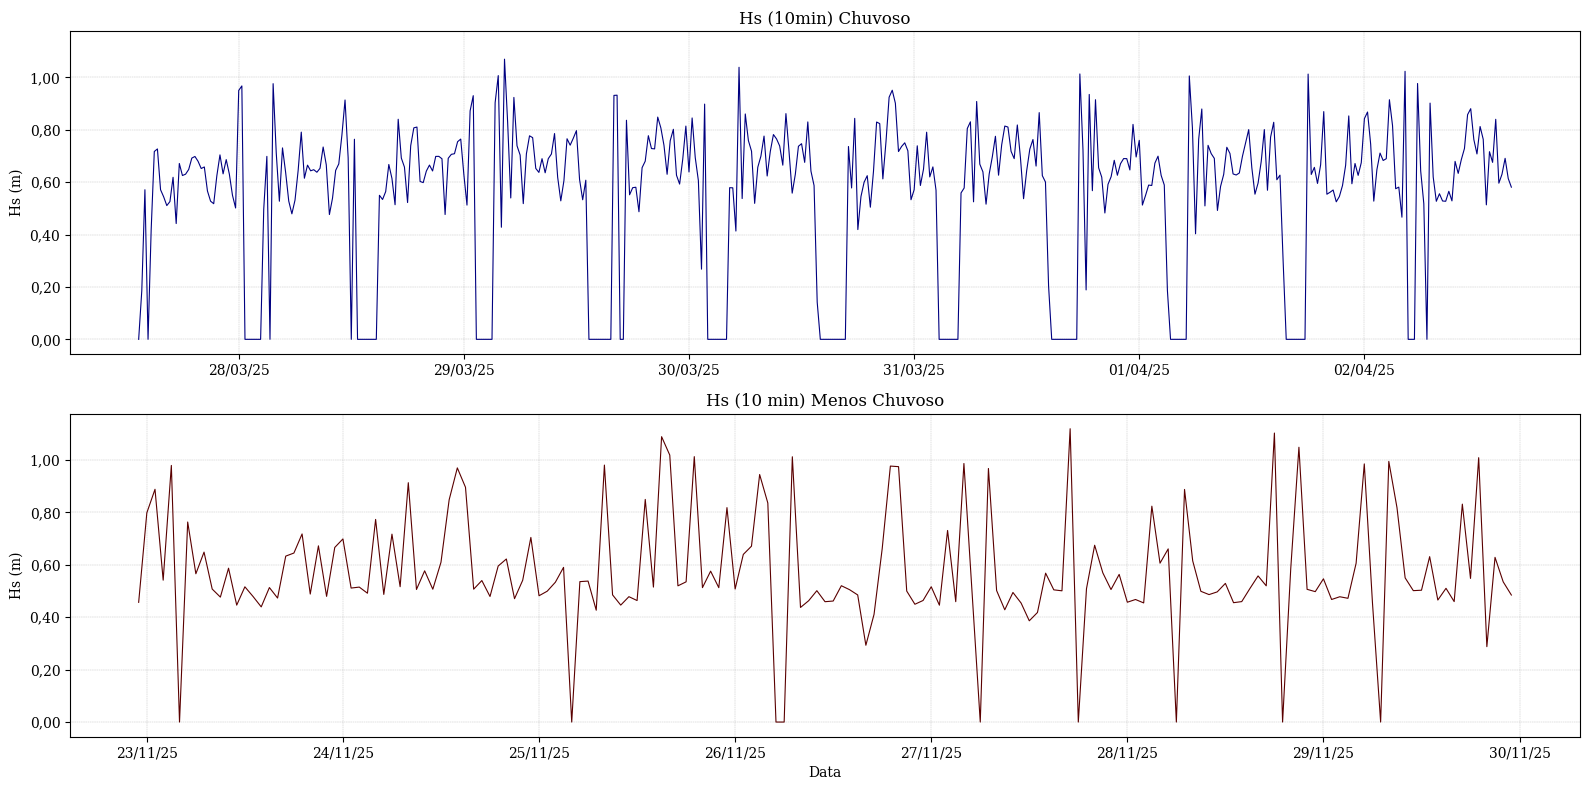

In [16]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# Chuvoso
ax[0].plot(
    df_Hs_10min_CHU_STRK['DataHora'],
    df_Hs_10min_CHU_STRK['Hs'],
    color='navy',
    linewidth=0.8
)

ax[0].set_title('Hs (10min) Chuvoso')
ax[0].set_ylabel('Hs (m)')

# grid discreto
ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

# virgula no eixo Y
ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(comma_formatter)
)

# menos chuvoso
ax[1].plot(
    df_Hs_10min_SEC_STRK['DataHora'],
    df_Hs_10min_SEC_STRK['Hs'],
    color='#5A0000',
    linewidth=0.8
)

ax[1].set_title('Hs (10 min) Menos Chuvoso')
ax[1].set_ylabel('Hs (m)')
ax[1].set_xlabel('Data')

# grid discreto
ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

# virgula no eixo Y
ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(comma_formatter)
)

# formato dd/mm/aa

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%d/%m/%y')
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%d/%m/%y')
)
plt.tight_layout()
plt.show()

# Hs 1H

In [17]:
df_Hs_1H_CHU_STRK = calc_hs_intervalo(
    df_strk_chu,
    '1H'
)

df_Hs_1H_SEC_STRK = calc_hs_intervalo(
    df_strk_sec,
    '1H'
)

/tmp/ipykernel_26284/1453054115.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(


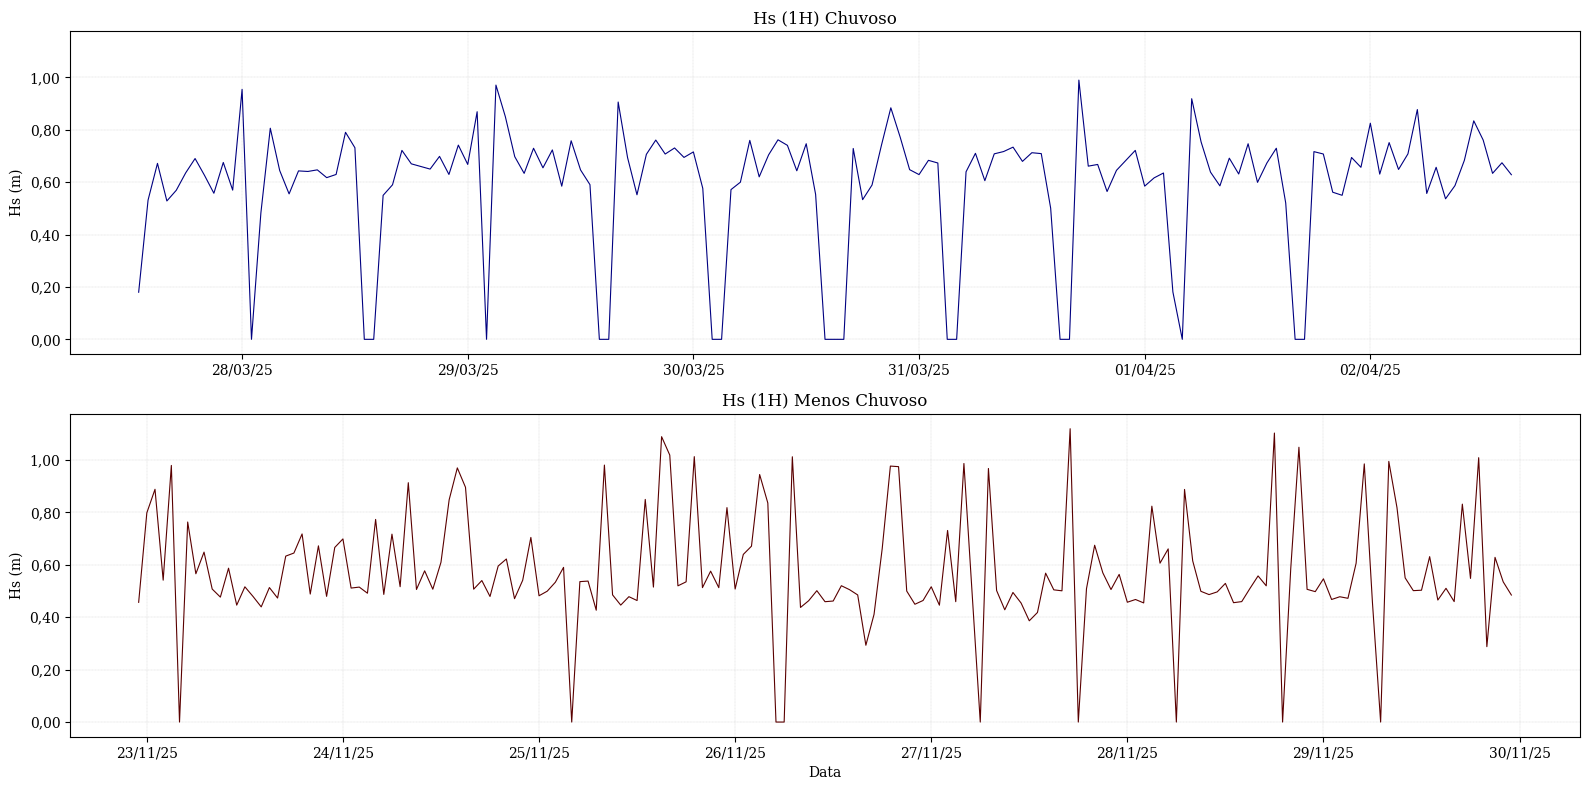

In [18]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# Chuvoso
ax[0].plot(
    df_Hs_1H_CHU_STRK['DataHora'],
    df_Hs_1H_CHU_STRK['Hs'],
    color='navy',
    linewidth=0.8
)

ax[0].set_title('Hs (1H) Chuvoso')
ax[0].set_ylabel('Hs (m)')

# grid discreto
ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

# virgula no eixo Y
ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(comma_formatter)
)

# menos chuvoso
ax[1].plot(
    df_Hs_1H_SEC_STRK['DataHora'],
    df_Hs_1H_SEC_STRK['Hs'],
    color='#5A0000',
    linewidth=0.8
)

ax[1].set_title('Hs (1H) Menos Chuvoso')
ax[1].set_ylabel('Hs (m)')
ax[1].set_xlabel('Data')

# grid discreto
ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

# virgula no eixo Y
ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(comma_formatter)
)

# formato dd/mm/aa

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%d/%m/%y')
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%d/%m/%y')
)
plt.tight_layout()
plt.show()

# Hs 3H

In [19]:
df_Hs_3H_CHU_STRK = calc_hs_intervalo(
    df_strk_chu,
    '3H'
)

df_Hs_3H_SEC_STRK = calc_hs_intervalo(
    df_strk_sec,
    '3H'
)

/tmp/ipykernel_26284/1453054115.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(


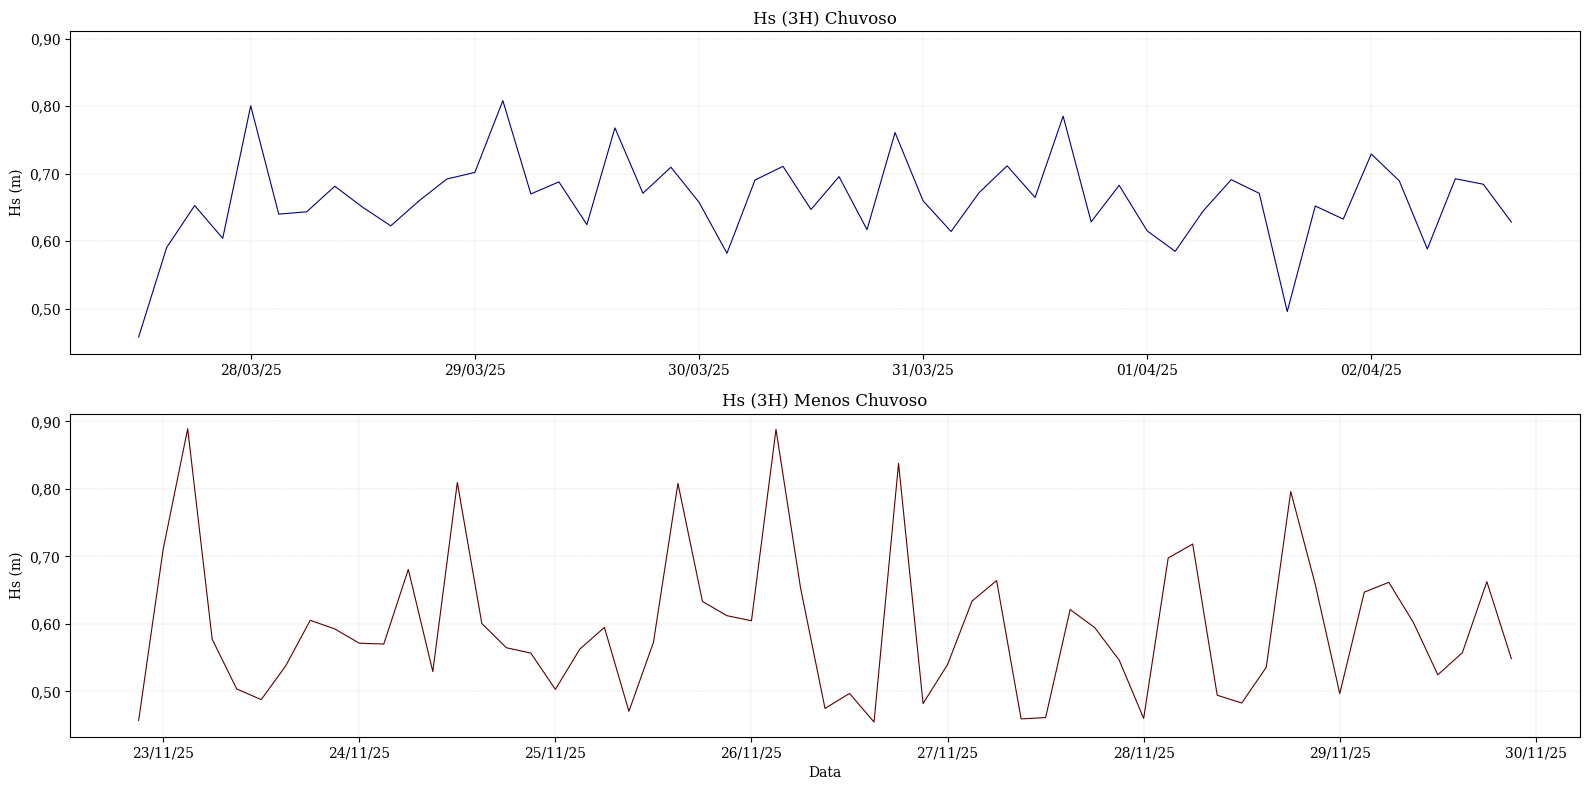

In [20]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# Chuvoso
ax[0].plot(
    df_Hs_3H_CHU_STRK['DataHora'],
    df_Hs_3H_CHU_STRK['Hs'],
    color='navy',
    linewidth=0.8
)

ax[0].set_title('Hs (3H) Chuvoso')
ax[0].set_ylabel('Hs (m)')

# grid discreto
ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

# virgula no eixo Y
ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(comma_formatter)
)

# menos chuvoso
ax[1].plot(
    df_Hs_3H_SEC_STRK['DataHora'],
    df_Hs_3H_SEC_STRK['Hs'],
    color='#5A0000',
    linewidth=0.8
)

ax[1].set_title('Hs (3H) Menos Chuvoso')
ax[1].set_ylabel('Hs (m)')
ax[1].set_xlabel('Data')

# grid discreto
ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

# virgula no eixo Y
ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(comma_formatter)
)

# formato dd/mm/aa

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%d/%m/%y')
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%d/%m/%y')
)
plt.tight_layout()
plt.show()

# Salvar arquivos

In [21]:
pasta_saida = (
    '/content/drive/MyDrive/Ondas/Dados/Refinados/'
)


# series completas
Strk_CHU.to_csv(
    pasta_saida + 'Strk_CHU.csv',
    index=False
)

Strk_SEC.to_csv(
    pasta_saida + 'Strk_SEC.csv',
    index=False
)

# Hs 10 min
df_Hs_10min_CHU_STRK.to_csv(
    pasta_saida + 'Hs_10min_CHU.csv',
    index=False
)

df_Hs_10min_SEC_STRK.to_csv(
    pasta_saida + 'Hs_10min_SEC.csv',
    index=False
)

# Hs 1H
df_Hs_1H_CHU_STRK.to_csv(
    pasta_saida + 'Hs_1H_CHU.csv',
    index=False
)

df_Hs_1H_SEC_STRK.to_csv(
    pasta_saida + 'Hs_1H_SEC.csv',
    index=False
)

# Hs 3H
df_Hs_3H_CHU_STRK.to_csv(
    pasta_saida + 'Hs_3H_CHU.csv',
    index=False
)

df_Hs_3H_SEC_STRK.to_csv(
    pasta_saida + 'Hs_3H_SEC.csv',
    index=False
)

print('Todos os arquivos foram salvos.')

Todos os arquivos foram salvos.
